In [1]:
# Installation automatique des dépendances requises dans le noyau Jupyter actuel
%pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# 📊 Étape 4 : Visualisation Multidimensionnelle (Squelette Étudiant)

Cette étape correspond au quatrième chapitre du cours. L'objectif est de concevoir des représentations visuelles premium pour identifier des tendances et insights clés à l'aide de votre package personnalisé de tracé `src.utils_viz`.

### 1. Préparation de l'environnement

In [2]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# accès src
sys.path.append(os.path.abspath(".."))

from src import data_clean as dc
from src import utils_viz as uv

# style graphique
uv.set_custom_style(theme="light")

%matplotlib inline

print("📊 Visualisation ready")

📊 Visualisation ready


### 2. Chargement du dataset enrichi

In [3]:
df = pd.read_csv("../data/processed/cleaned_data_sample.csv")

print("✔ Dataset chargé :", df.shape)

df.head()

# création features temporelles si possible
if "timestamp" in df.columns:
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df_feat = dc.feature_engineering(df, "timestamp")
else:
    df_feat = df.copy()

df_feat.head()

✔ Dataset chargé : (1460, 85)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,zone_type,coef_multiplicateur,HouseAge,LogSalePrice
0,1,60,RL,65.0,8450,Pave,Unknown,Reg,Lvl,AllPub,...,0,2,2008,WD,Normal,208500.0,Standard,1.0,5,12.247699
1,2,20,RL,80.0,9600,Pave,Unknown,Reg,Lvl,AllPub,...,0,5,2007,WD,Normal,181500.0,Premium,1.2,31,12.109016
2,3,60,RL,68.0,11250,Pave,Unknown,IR1,Lvl,AllPub,...,0,9,2008,WD,Normal,223500.0,Standard,1.0,7,12.317171
3,4,70,RL,60.0,9550,Pave,Unknown,IR1,Lvl,AllPub,...,0,2,2006,WD,Abnorml,140000.0,Premium,1.2,91,11.849405
4,5,60,RL,84.0,14260,Pave,Unknown,IR1,Lvl,AllPub,...,0,12,2008,WD,Normal,250000.0,Luxury,1.5,8,12.429220


### 3. Tracés et analyses graphiques

#### A. Évolution des tendances dans le temps

**À COMPLÉTER PAR L'ÉTUDIANT :**
Tracez les tendances globales à l'aide de la fonction `uv.plot_generic_trends`.

c:\Users\Simohamed\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


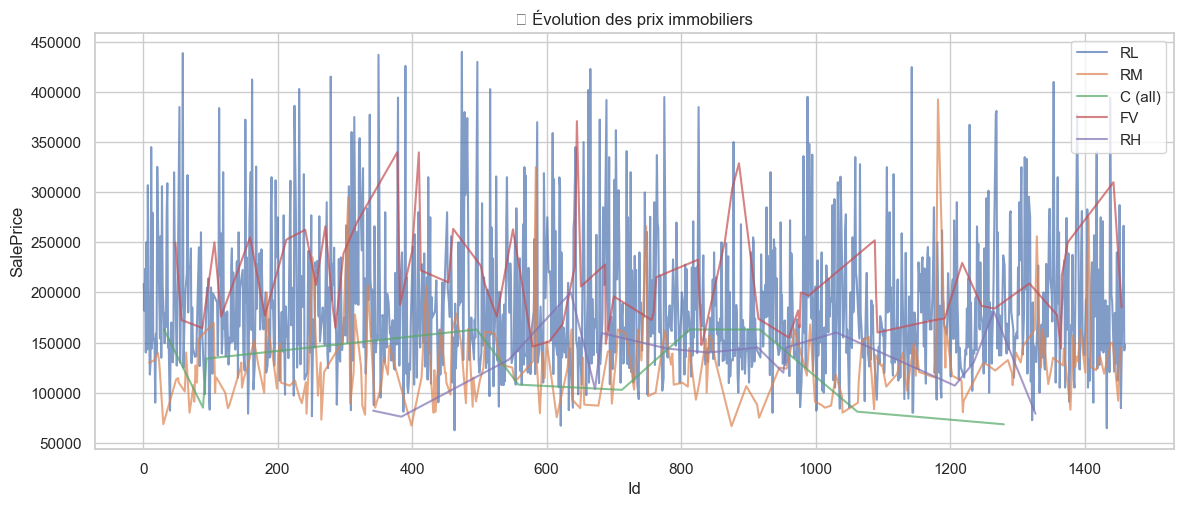

In [4]:
if "SalePrice" in df_feat.columns:
    fig1 = uv.plot_generic_trends(
        df_feat,
        x_col="Id" if "Id" in df_feat.columns else df_feat.index,
        y_col="SalePrice",
        group_col="MSZoning" if "MSZoning" in df_feat.columns else None
    )
    plt.title("📈 Évolution des prix immobiliers")
    plt.show()

c:\Users\Simohamed\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


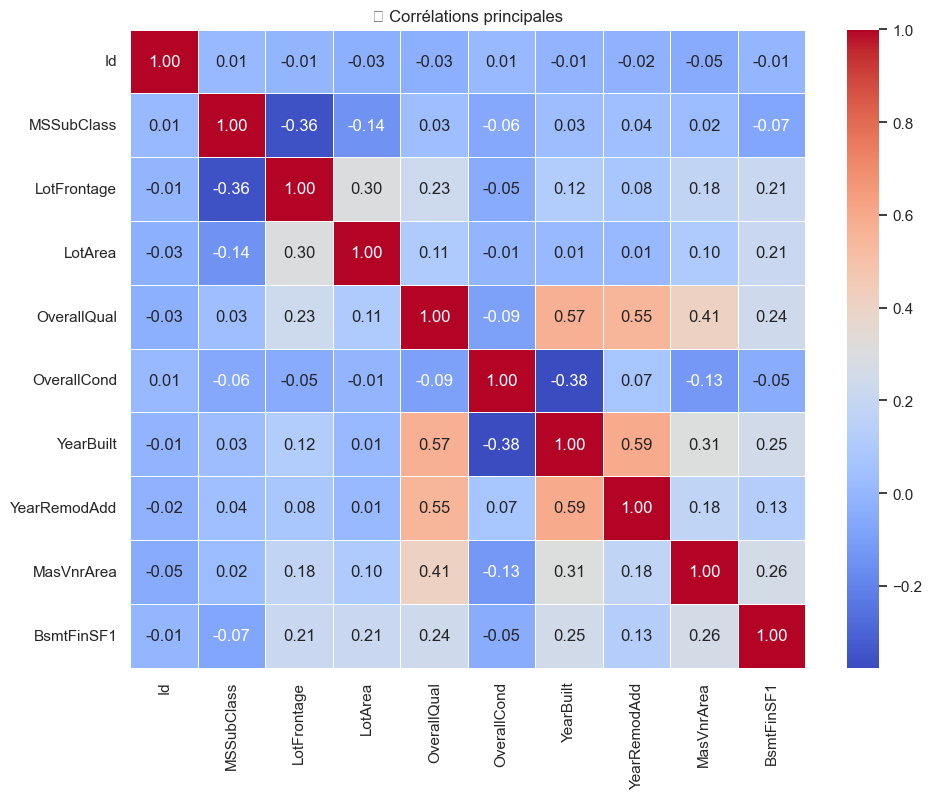

c:\Users\Simohamed\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127968 (\N{HOUSE BUILDING}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


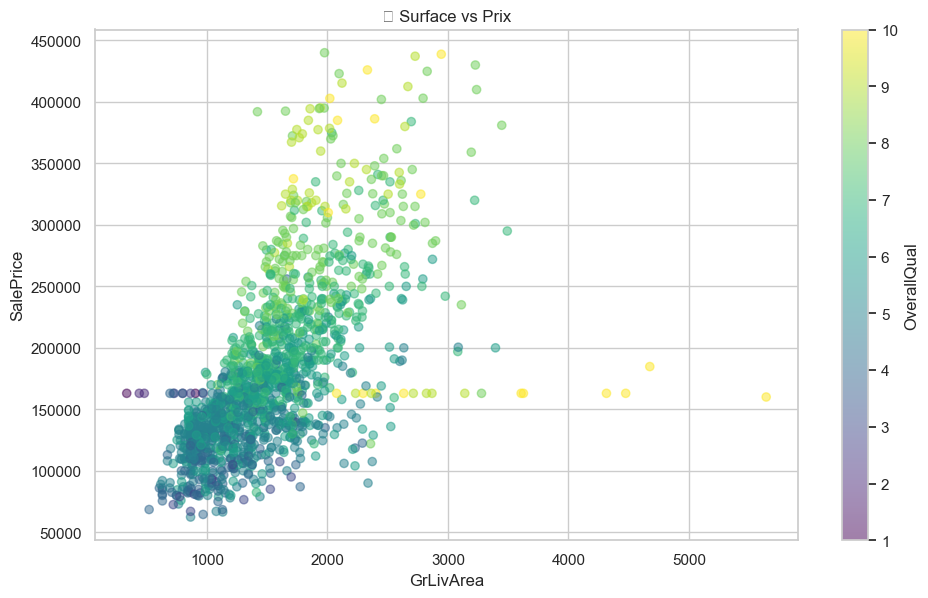


💡 INSIGHTS AUTOMATIQUES
- Prix moyen : 178093.71
- Prix médian : 163000.0
- Écart-type : 68071.43
- Corrélation Qualité/Prix : 0.743
💾 EDA sauvegardé
🚀 Visualisation terminée


In [5]:
num_cols = df_feat.select_dtypes(include=[np.number]).columns

fig2 = uv.plot_correlation_matrix(df_feat, list(num_cols[:10]))
plt.title("🔥 Corrélations principales")
plt.show()


if "GrLivArea" in df_feat.columns and "SalePrice" in df_feat.columns:
    fig3 = uv.plot_bivariate_scatter(
        df_feat,
        x_col="GrLivArea",
        y_col="SalePrice",
        color_col="OverallQual" if "OverallQual" in df_feat.columns else None
    )
    plt.title("🏠 Surface vs Prix")
    plt.show()

print("\n💡 INSIGHTS AUTOMATIQUES")

if "SalePrice" in df_feat.columns:
    print("- Prix moyen :", round(df_feat["SalePrice"].mean(), 2))
    print("- Prix médian :", round(df_feat["SalePrice"].median(), 2))
    print("- Écart-type :", round(df_feat["SalePrice"].std(), 2))

if "OverallQual" in df_feat.columns:
    print("- Corrélation Qualité/Prix :", 
          df_feat[["SalePrice", "OverallQual"]].corr().iloc[0,1].round(3))




df_feat.describe().to_csv("../data/processed/eda_summary.csv")

print("💾 EDA sauvegardé")
print("🚀 Visualisation terminée")

#### B. Carte de chaleur des corrélations

**À COMPLÉTER PAR L'ÉTUDIANT :**
Visualisez graphiquement les corrélations de Pearson à l'aide de `uv.plot_correlation_matrix`.

#### C. Nuage de points bivarié

**À COMPLÉTER PAR L'ÉTUDIANT :**
Générez une analyse graphique bivariée en utilisant `uv.plot_bivariate_scatter`.